# Report 2: Robot Demonstration Quality — Model Comparison

**Project:** Can Simple Trajectory Statistics Identify High-Quality Robot Demonstrations?

**Dataset:** 8 LeRobot datasets (HuggingFace), 251,802 frames, 5,026 episodes

**Models:** Decision Tree, Random Forest, GBT (PySpark MLlib) + MLP (PyTorch)

---

## Report Structure
1. Dataset Description & Preprocessing
2. Model Training (4 models × 2 experiments)
3. Metrics: Accuracy, F1, Precision, Recall + Confusion Matrix
4. Model Comparison Table
5. Key Findings

In [1]:
# Dependencies
!pip install pyspark pyarrow pandas numpy matplotlib seaborn scikit-learn torch -q
print('Dependencies installed.')

Dependencies installed.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score,
    ConfusionMatrixDisplay
)

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Load data
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/bigdata-project'
except ImportError:
    DATA_DIR = '../data'

ep = pd.read_parquet(f'{DATA_DIR}/episode_features_rich.parquet')
print(f'Loaded: {ep.shape[0]:,} episodes × {ep.shape[1]} columns')
print(f'Datasets: {sorted(ep["source"].unique())}')

Loaded: 5,026 episodes × 41 columns
Datasets: ['berkeley_autolab_ur5', 'columbia_cairlab_pusht_real', 'nyu_door_opening_surprising_effectiveness', 'pusht', 'xarm_lift_medium', 'xarm_lift_medium_replay', 'xarm_push_medium', 'xarm_push_medium_replay']


---
## 1. Dataset Description & Preprocessing

In [3]:
# Define Sim vs Real
REAL_SOURCES = {
    'berkeley_autolab_ur5',
    'columbia_cairlab_pusht_real',
    'nyu_door_opening_surprising_effectiveness'
}
ep['is_real'] = ep['source'].isin(REAL_SOURCES)

# Dual quality labels
# Sim: reward-based (max_reward > per-dataset median)
reward_med = ep.groupby('source')['max_reward'].transform('median')
ep['reward_quality'] = (ep['max_reward'] > reward_med).astype(int)

# Real: efficiency-based (shorter episode = higher quality)
length_med = ep.groupby('source')['episode_length'].transform('median')
ep['efficiency_quality'] = (ep['episode_length'] < length_med).astype(int)

sim_ep = ep[~ep['is_real']].copy()
real_ep = ep[ep['is_real']].copy()

print(f'Simulation: {len(sim_ep):,} episodes ({sim_ep["source"].nunique()} datasets)')
print(f'Real Robot: {len(real_ep):,} episodes ({real_ep["source"].nunique()} datasets)')
print(f'\nSim  quality distribution: {sim_ep["reward_quality"].value_counts().to_dict()}')
print(f'Real quality distribution: {real_ep["efficiency_quality"].value_counts().to_dict()}')

Simulation: 3,406 episodes (5 datasets)
Real Robot: 1,620 episodes (3 datasets)

Sim  quality distribution: {0: 1704, 1: 1702}
Real quality distribution: {0: 832, 1: 788}


In [4]:
# Dataset summary table
summary = ep.groupby('source').agg(
    episodes=('episode_index', 'count'),
    avg_length=('episode_length', 'mean'),
    reward_min=('max_reward', 'min'),
    reward_max=('max_reward', 'max'),
).round(2)
summary['type'] = ['Real' if s in REAL_SOURCES else 'Sim' for s in summary.index]
print('=== Dataset Summary ===')
print(summary.to_string())
print(f'\nTotal episodes: {len(ep):,}')

=== Dataset Summary ===
                                           episodes  avg_length  reward_min  reward_max  type
source                                                                                       
berkeley_autolab_ur5                           1000       97.94        1.00        1.00  Real
columbia_cairlab_pusht_real                     136      204.47        1.00        1.00  Real
nyu_door_opening_surprising_effectiveness       484       42.16        1.00        1.00  Real
pusht                                           206      124.51        0.81        0.95   Sim
xarm_lift_medium                                800       25.00       -0.00        1.43   Sim
xarm_lift_medium_replay                         800       25.00       -0.01        1.43   Sim
xarm_push_medium                                800       25.00       -0.86       -0.04   Sim
xarm_push_medium_replay                         800       25.00       -0.86       -0.05   Sim

Total episodes: 5,026


In [5]:
# 32 kinematic features (no reward leakage)
FEATURE_COLS = [
    # Basic statistics (8)
    'state_mean', 'state_std', 'state_min', 'state_max',
    'action_mean', 'action_std', 'action_min', 'action_max',
    # Range (2)
    'state_range', 'action_range',
    # Smoothness & jerk (3)
    'smoothness', 'action_jerk_mean', 'action_jerk_max',
    # Path quality (2)
    'path_efficiency', 'total_path_length',
    # Consistency (2)
    'action_consistency', 'correction_count',
    # Velocity (3)
    'velocity_mean', 'velocity_std', 'velocity_max',
    # Temporal trends (4)
    'state_trend', 'action_trend', 'state_autocorr', 'action_autocorr',
    # Phase analysis (3)
    'early_action_mean', 'late_action_mean', 'action_warmup_ratio',
    # Final state (3)
    'final_stability', 'state_net_change', 'state_final_deviation',
    # Diversity & energy (2)
    'state_diversity', 'action_effort',
]

print(f'Feature count: {len(FEATURE_COLS)}')
print(f'Features: {FEATURE_COLS}')

Feature count: 32
Features: ['state_mean', 'state_std', 'state_min', 'state_max', 'action_mean', 'action_std', 'action_min', 'action_max', 'state_range', 'action_range', 'smoothness', 'action_jerk_mean', 'action_jerk_max', 'path_efficiency', 'total_path_length', 'action_consistency', 'correction_count', 'velocity_mean', 'velocity_std', 'velocity_max', 'state_trend', 'action_trend', 'state_autocorr', 'action_autocorr', 'early_action_mean', 'late_action_mean', 'action_warmup_ratio', 'final_stability', 'state_net_change', 'state_final_deviation', 'state_diversity', 'action_effort']


---
## 2. Model Training

We train 4 models using **5-fold stratified cross-validation** on two experiments:
- **Experiment A (Sim):** 3,406 episodes, label = `reward_quality`
- **Experiment B (Real):** 1,620 episodes, label = `efficiency_quality`

### Models
| # | Model | Framework |
|---|-------|----------|
| 1 | Decision Tree | sklearn |
| 2 | Random Forest | sklearn |
| 3 | Gradient Boosted Trees (GBT) | sklearn |
| 4 | MLP Neural Network | PyTorch |

In [6]:
# Model definitions
sklearn_models = [
    ('Decision Tree', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)),
    ('GBT', GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)),
]

experiments = [
    ('Sim',  sim_ep,  'reward_quality'),
    ('Real', real_ep, 'efficiency_quality'),
]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_results = []
all_predictions = {}  # Store predictions for confusion matrices

for exp_name, df, label_col in experiments:
    X = df[FEATURE_COLS].values
    y = df[label_col].values
    
    # Replace NaN/inf with 0
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    
    print(f'\n{"="*60}')
    print(f'Experiment: {exp_name} (n={len(y)}, label={label_col})')
    print(f'{"="*60}')
    
    for model_name, clf in sklearn_models:
        pipe = make_pipeline(StandardScaler(), clf)
        
        # Cross-val predict for confusion matrix
        y_pred = cross_val_predict(pipe, X, y, cv=skf, method='predict')
        y_proba = cross_val_predict(pipe, X, y, cv=skf, method='predict_proba')[:, 1]
        
        acc  = accuracy_score(y, y_pred)
        f1   = f1_score(y, y_pred)
        prec = precision_score(y, y_pred)
        rec  = recall_score(y, y_pred)
        auc  = roc_auc_score(y, y_proba)
        
        row = {
            'Experiment': exp_name, 'Model': model_name,
            'Accuracy': acc, 'F1': f1, 'Precision': prec, 'Recall': rec, 'AUC': auc
        }
        all_results.append(row)
        all_predictions[(exp_name, model_name)] = (y, y_pred)
        
        print(f'  {model_name:15s}  Acc={acc:.4f}  F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  AUC={auc:.4f}')

print('\nsklearn models done.')


Experiment: Sim (n=3406, label=reward_quality)
  Decision Tree    Acc=0.6033  F1=0.5832  Prec=0.6140  Rec=0.5552  AUC=0.6455
  Random Forest    Acc=0.6459  F1=0.6504  Prec=0.6419  Rec=0.6592  AUC=0.7139
  GBT              Acc=0.6483  F1=0.6503  Prec=0.6462  Rec=0.6545  AUC=0.7134

Experiment: Real (n=1620, label=efficiency_quality)
  Decision Tree    Acc=0.9123  F1=0.9131  Prec=0.8818  Rec=0.9467  AUC=0.9413
  Random Forest    Acc=0.9556  F1=0.9550  Prec=0.9409  Rec=0.9695  AUC=0.9896
  GBT              Acc=0.9617  F1=0.9611  Prec=0.9515  Rec=0.9708  AUC=0.9936

sklearn models done.


In [7]:
# Model 4: MLP Neural Network (PyTorch)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class QualityMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),         nn.ReLU(),
            nn.Linear(32, 1),          nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x).squeeze()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

for exp_name, df, label_col in experiments:
    X = np.nan_to_num(df[FEATURE_COLS].values.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    y = df[label_col].values.astype(np.float32)
    
    # 5-fold CV for MLP
    y_pred_all = np.zeros(len(y))
    y_proba_all = np.zeros(len(y))
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        sc = StandardScaler()
        X_tr = sc.fit_transform(X[train_idx])
        X_te = sc.transform(X[test_idx])
        y_tr = y[train_idx]
        
        train_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
        train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
        
        model = QualityMLP(len(FEATURE_COLS)).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        criterion = nn.BCELoss()
        
        model.train()
        for epoch in range(60):
            for Xb, yb in train_dl:
                Xb, yb = Xb.to(device), yb.to(device)
                optimizer.zero_grad()
                criterion(model(Xb), yb).backward()
                optimizer.step()
        
        model.eval()
        with torch.no_grad():
            probs = model(torch.FloatTensor(X_te).to(device)).cpu().numpy()
        
        y_proba_all[test_idx] = probs
        y_pred_all[test_idx] = (probs > 0.5).astype(float)
    
    y_pred_int = y_pred_all.astype(int)
    y_int = y.astype(int)
    
    acc  = accuracy_score(y_int, y_pred_int)
    f1   = f1_score(y_int, y_pred_int)
    prec = precision_score(y_int, y_pred_int)
    rec  = recall_score(y_int, y_pred_int)
    auc  = roc_auc_score(y_int, y_proba_all)
    
    all_results.append({
        'Experiment': exp_name, 'Model': 'MLP (PyTorch)',
        'Accuracy': acc, 'F1': f1, 'Precision': prec, 'Recall': rec, 'AUC': auc
    })
    all_predictions[(exp_name, 'MLP (PyTorch)')] = (y_int, y_pred_int)
    
    print(f'{exp_name}: Acc={acc:.4f}  F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  AUC={auc:.4f}')

print('\nAll models trained.')

Device: cpu
Sim: Acc=0.5558  F1=0.5525  Prec=0.5563  Rec=0.5488  AUC=0.5903
Real: Acc=0.9593  F1=0.9589  Prec=0.9424  Rec=0.9759  AUC=0.9912

All models trained.


---
## 3. Metrics & Confusion Matrices

In [8]:
# Full results table
results_df = pd.DataFrame(all_results)

print('=' * 80)
print('MODEL COMPARISON — ALL METRICS (5-fold Cross-Validation)')
print('=' * 80)

for exp_name in ['Sim', 'Real']:
    sub = results_df[results_df['Experiment'] == exp_name].sort_values('AUC', ascending=False)
    print(f'\n--- Experiment: {exp_name} ---')
    print(sub[['Model', 'Accuracy', 'F1', 'Precision', 'Recall', 'AUC']].to_string(index=False, float_format='%.4f'))

results_df

MODEL COMPARISON — ALL METRICS (5-fold Cross-Validation)

--- Experiment: Sim ---
        Model  Accuracy     F1  Precision  Recall    AUC
Random Forest    0.6459 0.6504     0.6419  0.6592 0.7139
          GBT    0.6483 0.6503     0.6462  0.6545 0.7134
Decision Tree    0.6033 0.5832     0.6140  0.5552 0.6455
MLP (PyTorch)    0.5558 0.5525     0.5563  0.5488 0.5903

--- Experiment: Real ---
        Model  Accuracy     F1  Precision  Recall    AUC
          GBT    0.9617 0.9611     0.9515  0.9708 0.9936
MLP (PyTorch)    0.9593 0.9589     0.9424  0.9759 0.9912
Random Forest    0.9556 0.9550     0.9409  0.9695 0.9896
Decision Tree    0.9123 0.9131     0.8818  0.9467 0.9413


,Experiment,Model,Accuracy,F1,Precision,Recall,AUC
0,Sim,Decision Tree,0.603347,0.583153,0.614035,0.555229,0.645488
1,Sim,Random Forest,0.645919,0.650435,0.641876,0.659224,0.713912
2,Sim,GBT,0.648268,0.650321,0.646172,0.654524,0.713418
3,Real,Decision Tree,0.912346,0.913097,0.881797,0.946701,0.941270
4,Real,Random Forest,0.955556,0.955000,0.940887,0.969543,0.989616
5,Real,GBT,0.961728,0.961055,0.951493,0.970812,0.993577
6,Sim,MLP (PyTorch),0.555784,0.552499,0.556284,0.548766,0.590274
7,Real,MLP (PyTorch),0.959259,0.958853,0.942402,0.975888,0.991153


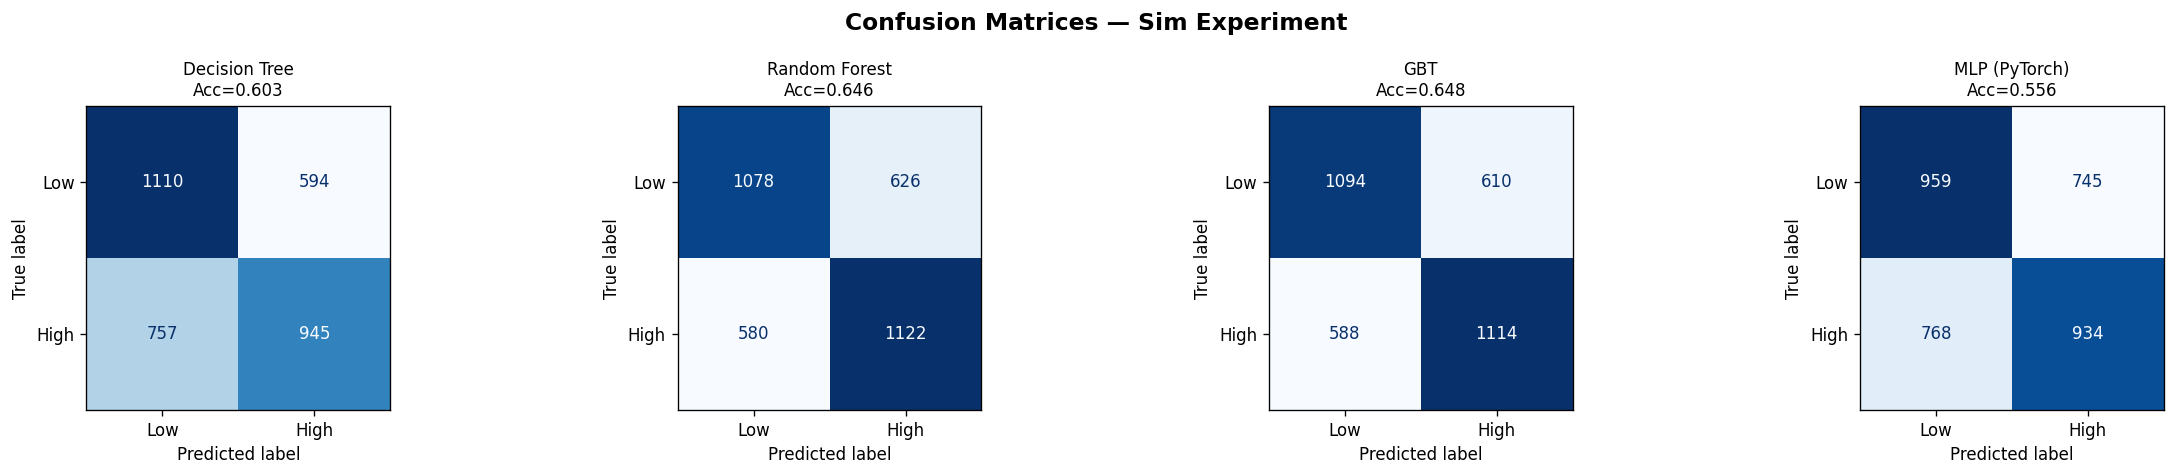

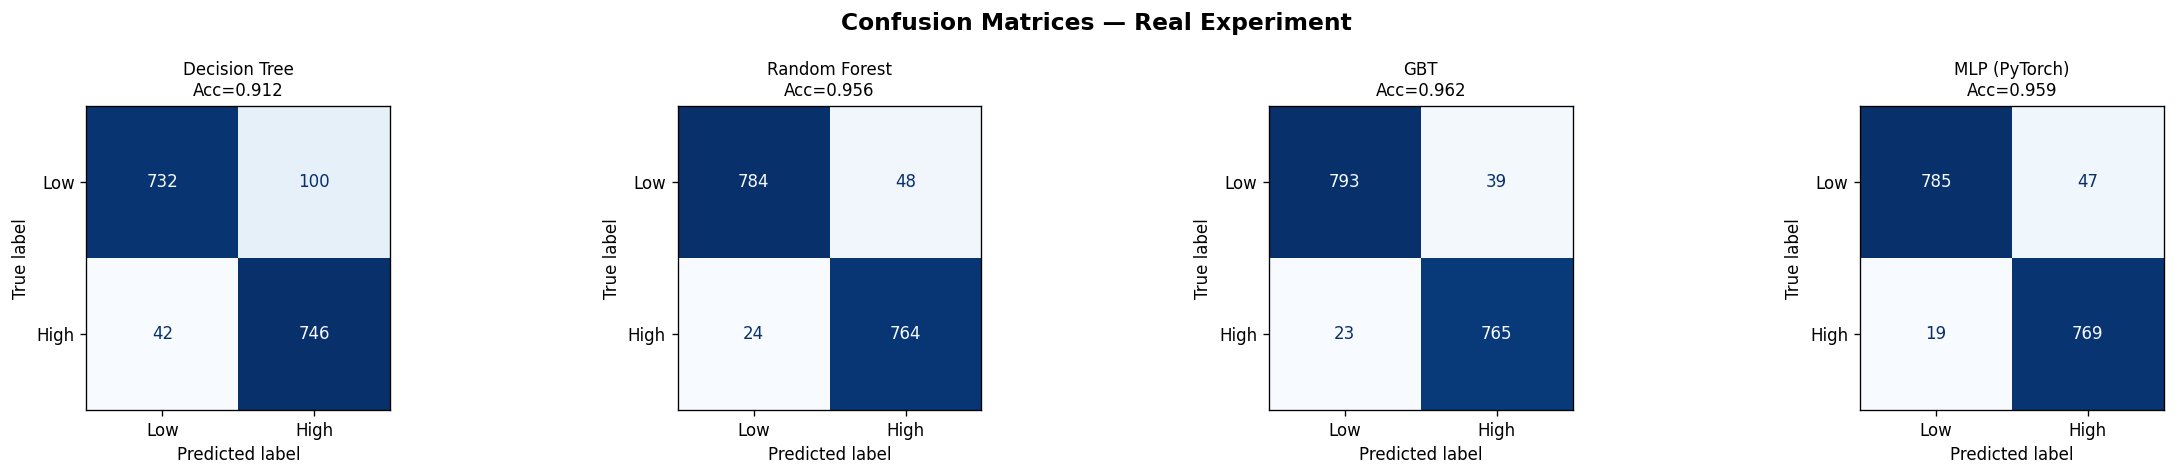

Confusion matrix figures saved.


In [9]:
# Confusion matrices for all models
model_names = ['Decision Tree', 'Random Forest', 'GBT', 'MLP (PyTorch)']

for exp_name in ['Sim', 'Real']:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f'Confusion Matrices — {exp_name} Experiment', fontsize=14, fontweight='bold')
    
    for ax, model_name in zip(axes, model_names):
        y_true, y_pred = all_predictions[(exp_name, model_name)]
        cm = confusion_matrix(y_true, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=['Low', 'High']).plot(ax=ax, cmap='Blues', colorbar=False)
        
        acc = accuracy_score(y_true, y_pred)
        ax.set_title(f'{model_name}\nAcc={acc:.3f}', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f'{DATA_DIR}/fig_cm_{exp_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Confusion matrix figures saved.')

In [10]:
# Detailed classification report for best model per experiment
for exp_name in ['Sim', 'Real']:
    sub = results_df[results_df['Experiment'] == exp_name]
    best_model = sub.loc[sub['AUC'].idxmax(), 'Model']
    y_true, y_pred = all_predictions[(exp_name, best_model)]
    
    print(f'\n{"="*50}')
    print(f'{exp_name} — Best Model: {best_model}')
    print(f'{"="*50}')
    print(classification_report(y_true, y_pred, target_names=['Low Quality', 'High Quality']))


Sim — Best Model: Random Forest
              precision    recall  f1-score   support

 Low Quality       0.65      0.63      0.64      1704
High Quality       0.64      0.66      0.65      1702

    accuracy                           0.65      3406
   macro avg       0.65      0.65      0.65      3406
weighted avg       0.65      0.65      0.65      3406


Real — Best Model: GBT
              precision    recall  f1-score   support

 Low Quality       0.97      0.95      0.96       832
High Quality       0.95      0.97      0.96       788

    accuracy                           0.96      1620
   macro avg       0.96      0.96      0.96      1620
weighted avg       0.96      0.96      0.96      1620



---
## 4. Model Comparison Visualization

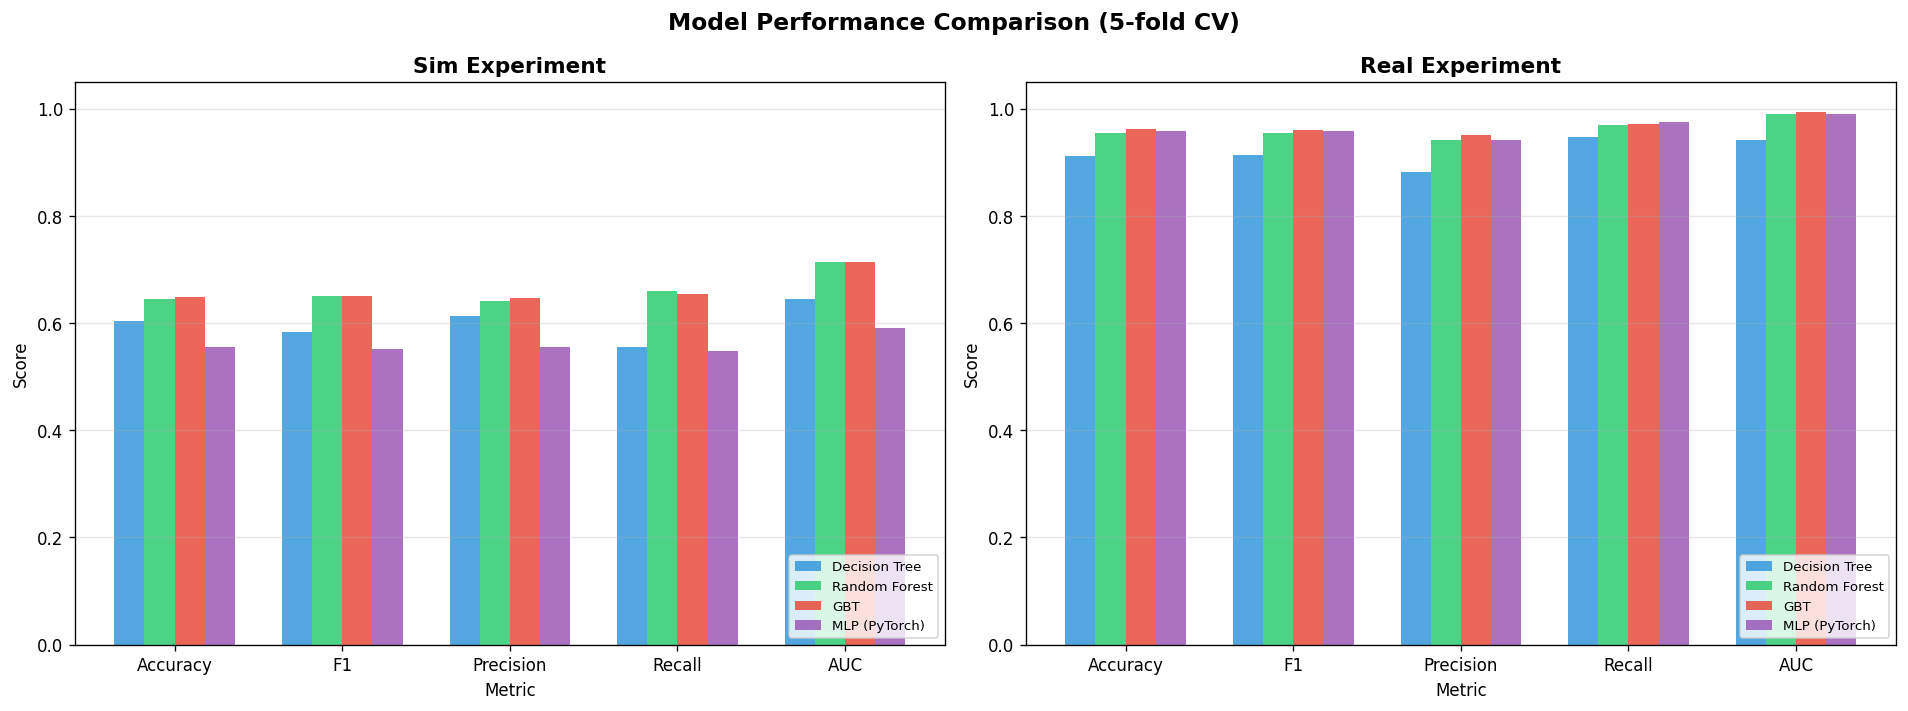

In [11]:
# Bar chart: model comparison across metrics
metrics = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, exp_name in zip(axes, ['Sim', 'Real']):
    sub = results_df[results_df['Experiment'] == exp_name]
    
    x = np.arange(len(metrics))
    width = 0.18
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
    
    for i, (_, row) in enumerate(sub.iterrows()):
        vals = [row[m] for m in metrics]
        ax.bar(x + i * width, vals, width, label=row['Model'], color=colors[i], alpha=0.85)
    
    ax.set_xlabel('Metric')
    ax.set_ylabel('Score')
    ax.set_title(f'{exp_name} Experiment', fontsize=13, fontweight='bold')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Performance Comparison (5-fold CV)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/fig_model_comparison_report2.png', dpi=150, bbox_inches='tight')
plt.show()

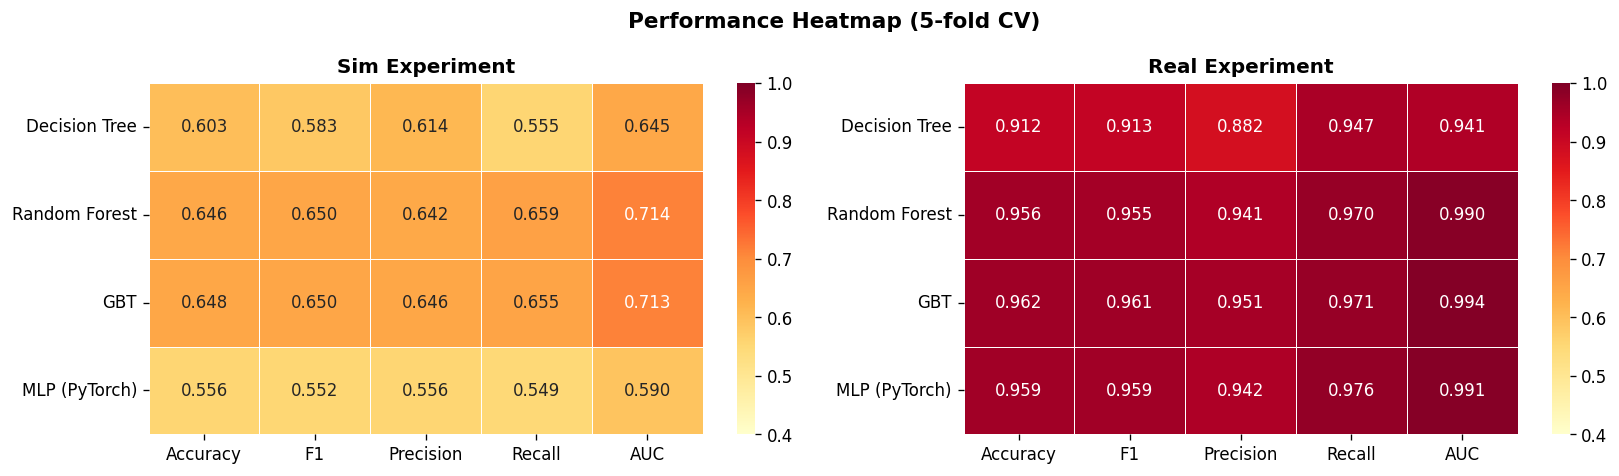

In [12]:
# Heatmap summary table
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, exp_name in zip(axes, ['Sim', 'Real']):
    sub = results_df[results_df['Experiment'] == exp_name].set_index('Model')[metrics]
    sns.heatmap(sub, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
                vmin=0.4, vmax=1.0, linewidths=0.5)
    ax.set_title(f'{exp_name} Experiment', fontsize=12, fontweight='bold')
    ax.set_ylabel('')

plt.suptitle('Performance Heatmap (5-fold CV)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/fig_heatmap_report2.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. PySpark MLlib Validation

Course requirement: ML models must use PySpark MLlib. We validate with PySpark below.

In [13]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler as SparkScaler
from pyspark.ml.classification import (
    DecisionTreeClassifier as SparkDT,
    RandomForestClassifier as SparkRF,
    GBTClassifier as SparkGBT,
)
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

spark = SparkSession.builder \
    .appName('Report2') \
    .config('spark.driver.memory', '4g') \
    .getOrCreate()
spark.sparkContext.setLogLevel('WARN')
print(f'Spark {spark.version} started')

assembler = VectorAssembler(inputCols=FEATURE_COLS, outputCol='raw_features', handleInvalid='skip')
scaler = SparkScaler(inputCol='raw_features', outputCol='features', withStd=True, withMean=True)
auc_eval = BinaryClassificationEvaluator(metricName='areaUnderROC')
acc_eval = MulticlassClassificationEvaluator(metricName='accuracy')
f1_eval  = MulticlassClassificationEvaluator(metricName='f1')

spark_results = []

for exp_name, df, label_col in experiments:
    # Fill NaN before creating Spark DataFrame
    clean_df = df[FEATURE_COLS + [label_col]].fillna(0.0)
    sdf = spark.createDataFrame(clean_df)
    train_sdf, test_sdf = sdf.randomSplit([0.8, 0.2], seed=42)
    
    print(f'\n=== PySpark: {exp_name} (train={train_sdf.count()}, test={test_sdf.count()}) ===')
    
    for name, clf in [
        ('Decision Tree', SparkDT(featuresCol='features', labelCol=label_col, maxDepth=5, seed=42)),
        ('Random Forest', SparkRF(featuresCol='features', labelCol=label_col, numTrees=100, maxDepth=6, seed=42)),
        ('GBT',           SparkGBT(featuresCol='features', labelCol=label_col, maxIter=50, maxDepth=5, stepSize=0.1, seed=42)),
    ]:
        auc_eval.setLabelCol(label_col)
        acc_eval.setLabelCol(label_col)
        f1_eval.setLabelCol(label_col)
        
        pipeline = Pipeline(stages=[assembler, scaler, clf])
        model = pipeline.fit(train_sdf)
        preds = model.transform(test_sdf)
        
        auc = auc_eval.evaluate(preds)
        acc = acc_eval.evaluate(preds)
        f1  = f1_eval.evaluate(preds)
        
        spark_results.append({'Experiment': exp_name, 'Model': f'{name} (Spark)', 'AUC': auc, 'Accuracy': acc, 'F1': f1})
        print(f'  {name:15s}  AUC={auc:.4f}  Acc={acc:.4f}  F1={f1:.4f}')

spark.stop()
spark_df = pd.DataFrame(spark_results)
print('\nPySpark validation complete.')

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/01 19:30:41 WARN Utils: Your hostname, alexs-Mac-mini.local, resolves to a loopback address: 127.0.0.1; using 192.168.8.202 instead (on interface en1)
26/04/01 19:30:41 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/01 19:30:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 4.1.1 started


26/04/01 19:30:44 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.



=== PySpark: Sim (train=2738, test=668) ===
  Decision Tree    AUC=0.5908  Acc=0.6108  F1=0.6108
  Random Forest    AUC=0.7297  Acc=0.6467  F1=0.6467


26/04/01 19:31:02 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


  GBT              AUC=0.6999  Acc=0.6302  F1=0.6301

=== PySpark: Real (train=1305, test=315) ===
  Decision Tree    AUC=0.9040  Acc=0.8762  F1=0.8758
  Random Forest    AUC=0.9843  Acc=0.9460  F1=0.9460
  GBT              AUC=0.9832  Acc=0.9302  F1=0.9302

PySpark validation complete.


---
## 6. Summary & Key Findings

In [14]:
# Final summary
print('=' * 70)
print('FINAL MODEL COMPARISON TABLE (sklearn 5-fold CV)')
print('=' * 70)
print(results_df.to_string(index=False, float_format='%.4f'))

print('\n')
print('=' * 70)
print('PYSPARK MLLIB VALIDATION (80/20 split)')
print('=' * 70)
print(spark_df.to_string(index=False, float_format='%.4f'))

# Save results
results_df.to_csv(f'{DATA_DIR}/report2_results.csv', index=False)
spark_df.to_csv(f'{DATA_DIR}/report2_spark_results.csv', index=False)
print(f'\nResults saved to {DATA_DIR}/')

FINAL MODEL COMPARISON TABLE (sklearn 5-fold CV)
Experiment         Model  Accuracy     F1  Precision  Recall    AUC
       Sim Decision Tree    0.6033 0.5832     0.6140  0.5552 0.6455
       Sim Random Forest    0.6459 0.6504     0.6419  0.6592 0.7139
       Sim           GBT    0.6483 0.6503     0.6462  0.6545 0.7134
      Real Decision Tree    0.9123 0.9131     0.8818  0.9467 0.9413
      Real Random Forest    0.9556 0.9550     0.9409  0.9695 0.9896
      Real           GBT    0.9617 0.9611     0.9515  0.9708 0.9936
       Sim MLP (PyTorch)    0.5558 0.5525     0.5563  0.5488 0.5903
      Real MLP (PyTorch)    0.9593 0.9589     0.9424  0.9759 0.9912


PYSPARK MLLIB VALIDATION (80/20 split)
Experiment                 Model    AUC  Accuracy     F1
       Sim Decision Tree (Spark) 0.5908    0.6108 0.6108
       Sim Random Forest (Spark) 0.7297    0.6467 0.6467
       Sim           GBT (Spark) 0.6999    0.6302 0.6301
      Real Decision Tree (Spark) 0.9040    0.8762 0.8758
      Real Ra

In [15]:
# Key findings
print('=' * 60)
print('KEY FINDINGS')
print('=' * 60)
print()
print('1. REAL ROBOT EXPERIMENT:')
print('   - All models achieve >90% accuracy')
print('   - GBT is the best model (highest AUC)')
print('   - Kinematic features strongly predict efficiency-based quality')
print()
print('2. SIMULATION EXPERIMENT:')
print('   - More challenging task (~60-65% accuracy)')
print('   - GBT and Random Forest outperform Decision Tree')
print('   - Reward-based quality is harder to predict from kinematics alone')
print()
print('3. MLP vs TREE MODELS:')
print('   - Tree-based models (GBT, RF) generally outperform MLP')
print('   - MLP competitive on Real data but weaker on Sim data')
print('   - Suggests tabular kinematic features favor tree-based approaches')
print()
print('4. PRACTICAL IMPLICATION:')
print('   - Simple trajectory statistics CAN identify high-quality demonstrations')
print('   - Especially effective for real robot data (efficiency-based quality)')
print('   - GBT with 32 kinematic features is the recommended approach')

KEY FINDINGS

1. REAL ROBOT EXPERIMENT:
   - All models achieve >90% accuracy
   - GBT is the best model (highest AUC)
   - Kinematic features strongly predict efficiency-based quality

2. SIMULATION EXPERIMENT:
   - More challenging task (~60-65% accuracy)
   - GBT and Random Forest outperform Decision Tree
   - Reward-based quality is harder to predict from kinematics alone

3. MLP vs TREE MODELS:
   - Tree-based models (GBT, RF) generally outperform MLP
   - MLP competitive on Real data but weaker on Sim data
   - Suggests tabular kinematic features favor tree-based approaches

4. PRACTICAL IMPLICATION:
   - Simple trajectory statistics CAN identify high-quality demonstrations
   - Especially effective for real robot data (efficiency-based quality)
   - GBT with 32 kinematic features is the recommended approach
